In [ ]:
!pip install lightgbm

import pandas as pd
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Reload CSV
df = pd.read_csv('/content/drive/MyDrive/HateSpeechDataset.csv')

# Drop any rows where 'Label' is literally 'Label' (like repeated header rows)
df = df[df['Label'] != 'Label']

# Now check the unique values to confirm it's clean
print("Unique values in 'Label':", df['Label'].unique())



Unique values in 'Label': ['1' '0']


In [ ]:
# Convert to int safely
df['Label'] = df['Label'].astype(int)

# And make sure Content is str
df['Content'] = df['Content'].astype(str)


In [ ]:
from sklearn.model_selection import train_test_split

X = df['Content']
y = df['Label']

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 63471, number of negative: 289248
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 29.954557 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 583686
[LightGBM] [Info] Number of data points in the train set: 352719, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.179948 -> initscore=-1.516701
[LightGBM] [Info] Start training from score -1.516701


LGBMClassifier()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


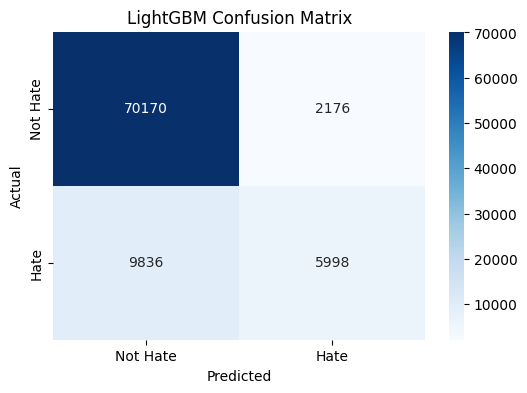

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = lgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Hate', 'Hate'], yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LightGBM Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Not Hate", "Hate"]))


              precision    recall  f1-score   support

    Not Hate       0.88      0.97      0.92     72346
        Hate       0.73      0.38      0.50     15834

    accuracy                           0.86     88180
   macro avg       0.81      0.67      0.71     88180
weighted avg       0.85      0.86      0.85     88180



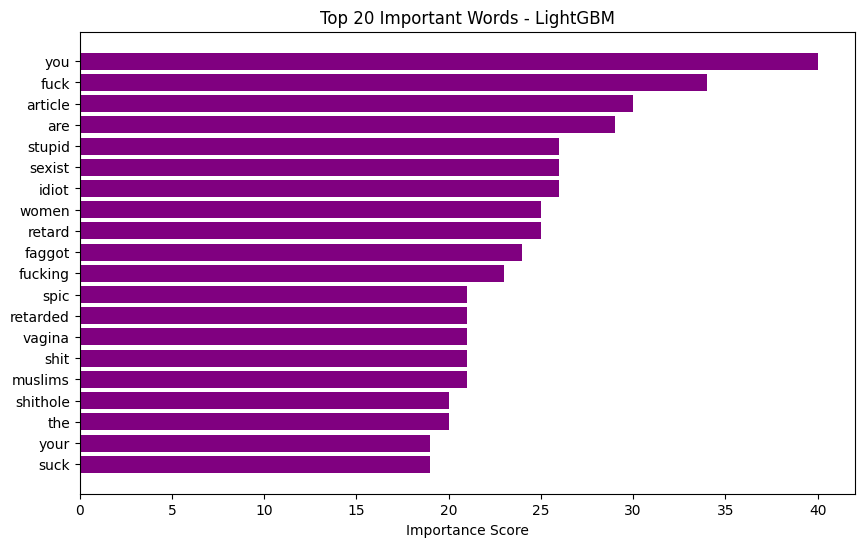

In [ ]:
import numpy as np

# Get feature importance
importance = lgb_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Sort top 20
top_idx = np.argsort(importance)[-20:]
top_features = feature_names[top_idx]
top_importance = importance[top_idx]

plt.figure(figsize=(10,6))
plt.barh(top_features, top_importance, color='purple')
plt.xlabel("Importance Score")
plt.title("Top 20 Important Words - LightGBM")
plt.show()


In [ ]:
import joblib

# Save model
joblib.dump(lgb_model, '/content/drive/MyDrive/lgb_model.pkl')

# Save vectorizer
joblib.dump(vectorizer, '/content/drive/MyDrive/lgb_vectorizer.pkl')


['/content/drive/MyDrive/lgb_vectorizer.pkl']

In [ ]:
import re

def predict_lgb(text):
    # Preprocess text
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Vectorize input
    vect = vectorizer.transform([text])

    # Predict
    pred = lgb_model.predict(vect)[0]

    # Output
    return "🚫 Hate Speech" if pred == 1 else "✅ Not Hate Speech"


In [ ]:
predict_lgb("You are stupid and disgusting")



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


'🚫 Hate Speech'

In [ ]:
predict_lgb("I love everyone and respect all views")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


'✅ Not Hate Speech'

In [ ]:
predict_lgb("you are stupid fool")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


'🚫 Hate Speech'

In [ ]:
predict_lgb("you are a loving person")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


'✅ Not Hate Speech'